In [ ]:
# Import standard scientific libraries and machine learning modules
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

# Configure default visualization settings for high-contrast presentation
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

In [ ]:
# Load the dataset and inspect initial structural properties
# Using latin-1 encoding to handle international order characters safely
file_path = "DataCoSupplyChainDataset.csv"
df = pd.read_csv(file_path, encoding="latin-1")

print(
    f"Dataset successfully loaded with {df.shape[0]:,} rows and"
    f" {df.shape[1]} columns."
)

# Standardize column headers: strip whitespace, convert to lowercase, and replace spaces with underscores
df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "")
    .str.replace(")", "")
)

# Display sample of initial columns and missing value counts
null_counts = df.isnull().sum()
columns_with_nulls = null_counts[null_counts > 0]
print("\n--- Columns with Missing Values ---")
print(
    columns_with_nulls.to_frame(name="Missing Count")
    .assign(
        Percentage=lambda x: (x["Missing Count"] / len(df) * 100).round(2)
    )
    .to_string()
)

Dataset successfully loaded with 15,917 rows and 53 columns.

--- Columns with Missing Values ---
                          Missing Count  Percentage
order_zipcode                     14007       88.00
product_card_id                       1        0.01
product_category_id                   1        0.01
product_description               15917      100.00
product_image                         1        0.01
product_name                          1        0.01
product_price                         1        0.01
product_status                        1        0.01
shipping_date_dateorders              1        0.01
shipping_mode                         1        0.01


In [ ]:
#  Comprehensive quality checks (duplicates, negative values, target distribution)

# 1. Duplicates check
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate records: {duplicate_rows}")

# 2. Check target column balance
target_col = "late_delivery_risk"
target_distribution = df[target_col].value_counts(normalize=True) * 100
print("\n--- Target Variable Distribution (late_delivery_risk) ---")
print(
    f"On-time or Early (0): {target_distribution.get(0, 0):.2f}%\nLate"
    f" Delivery (1): {target_distribution.get(1, 0):.2f}%"
)

# 3. Logical constraints validation: sales and shipping days cannot be negative
negative_days = (df["days_for_shipment_scheduled"] < 0).sum()
negative_prices = (df["order_item_product_price"] < 0).sum()

print(f"Records with negative scheduled days: {negative_days} (Expected: 0)")
print(f"Records with negative product prices: {negative_prices} (Expected: 0)")

# 4. Outlier detection on core numerical features using IQR
key_numeric_features = [
    "order_item_quantity",
    "order_item_product_price",
    "sales",
    "days_for_shipment_scheduled",
]

print("\n--- Outlier Boundaries (IQR Method) ---")
for col in key_numeric_features:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5 * iqr
  upper_bound = q3 + 1.5 * iqr
  outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
  print(
      f"Feature '{col}': {outlier_count:,} outliers detected outside"
      f" [{lower_bound:.2f}, {upper_bound:.2f}]"
  )

Number of duplicate records: 0

--- Target Variable Distribution (late_delivery_risk) ---
On-time or Early (0): 47.88%
Late Delivery (1): 52.12%
Records with negative scheduled days: 0 (Expected: 0)
Records with negative product prices: 0 (Expected: 0)

--- Outlier Boundaries (IQR Method) ---
Feature 'order_item_quantity': 0 outliers detected outside [-3.50, 8.50]
Feature 'order_item_product_price': 2,527 outliers detected outside [-69.99, 249.98]
Feature 'sales': 59 outliers detected outside [-149.98, 569.91]
Feature 'days_for_shipment_scheduled': 0 outliers detected outside [-1.00, 7.00]


In [ ]:
#  Drop redundant, private, and leakage-prone columns

# Exclude columns causing data leakage (real shipping days, delivery status)
# Exclude high-cardinality/PII text (names, emails, passwords, image URLs)
leakage_and_pii_columns = [
    "days_for_shipping_real",  # Leakage: known only after delivery
    "delivery_status",  # Leakage: directly reveals target
    "customer_email",
    "customer_password",
    "customer_fname",
    "customer_lname",
    "customer_street",
    "product_image",
    "product_description",
    "order_zipcode",
    "customer_zipcode",
    "order_item_cardprod_id",
    "order_item_id",
    "order_customer_id",
    "product_card_id",
    "order_id",
]

df_clean = df.drop(
    columns=[c for c in leakage_and_pii_columns if c in df.columns]
).copy()

# Drop columns that have more than 50% missing data
high_null_cols = df_clean.columns[df_clean.isnull().mean() > 0.50].tolist()
df_clean = df_clean.drop(columns=high_null_cols)

# Impute remaining missing values for categorical/numeric columns if any
for col in df_clean.columns:
  if df_clean[col].isnull().sum() > 0:
    if df_clean[col].dtype == "object":
      df_clean[col] = df_clean[col].fillna("Unknown")
    else:
      df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print(f"Cleaned dataset shape: {df_clean.shape[0]:,} rows, {df_clean.shape[1]} features.")

Cleaned dataset shape: 15,917 rows, 37 features.


/tmp/ipykernel_648/2529761583.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_648/2529761583.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["On-Time/Early (0)", "Late (1)"])
/tmp/ipykernel_648/2529761583.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


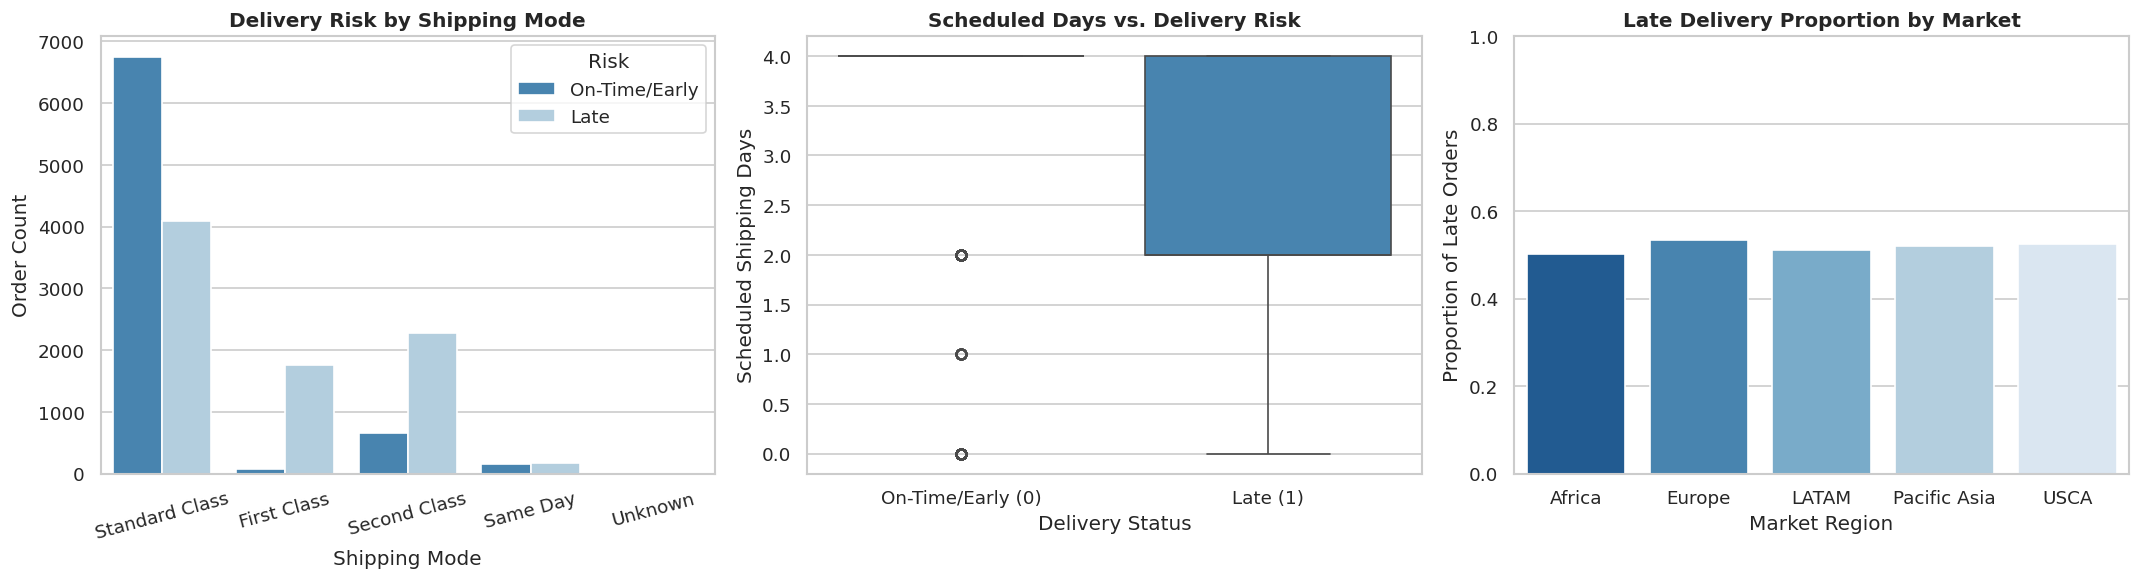

In [ ]:
#  Exploratory Data Analysis (EDA) visualizations

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Late delivery risk across different Shipping Modes
sns.countplot(
    data=df_clean,
    x="shipping_mode",
    hue="late_delivery_risk",
    palette="Blues_r",
    ax=axes[0],
)
axes[0].set_title(
    "Delivery Risk by Shipping Mode", fontsize=12, fontweight="bold"
)
axes[0].set_xlabel("Shipping Mode")
axes[0].set_ylabel("Order Count")
axes[0].legend(title="Risk", labels=["On-Time/Early", "Late"])
axes[0].tick_params(axis="x", rotation=15)

# Plot 2: Impact of Scheduled Shipment Days on Late Risk
sns.boxplot(
    data=df_clean,
    x="late_delivery_risk",
    y="days_for_shipment_scheduled",
    palette="Blues",
    ax=axes[1],
)
axes[1].set_title(
    "Scheduled Days vs. Delivery Risk", fontsize=12, fontweight="bold"
)
axes[1].set_xticklabels(["On-Time/Early (0)", "Late (1)"])
axes[1].set_xlabel("Delivery Status")
axes[1].set_ylabel("Scheduled Shipping Days")

# Plot 3: Risk across top geographic markets
top_markets = df_clean["market"].value_counts().nlargest(5).index
market_risk = (
    df_clean[df_clean["market"].isin(top_markets)]
    .groupby("market")["late_delivery_risk"]
    .mean()
    .reset_index()
)

sns.barplot(
    data=market_risk,
    x="market",
    y="late_delivery_risk",
    palette="Blues_r",
    ax=axes[2],
)
axes[2].set_title(
    "Late Delivery Proportion by Market", fontsize=12, fontweight="bold"
)
axes[2].set_xlabel("Market Region")
axes[2].set_ylabel("Proportion of Late Orders")
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [ ]:
#  Feature engineering, categorical encoding, and dataset reduction for optimal performance

# Extract temporal features from order date if present
if "order_date_dateorders" in df_clean.columns:
  df_clean["order_date"] = pd.to_datetime(
      df_clean["order_date_dateorders"], errors="coerce"
  )
  df_clean["order_hour"] = df_clean["order_date"].dt.hour
  df_clean["order_dayofweek"] = df_clean["order_date"].dt.dayofweek
  df_clean = df_clean.drop(
      columns=[
          "order_date",
          "order_date_dateorders",
          "shipping_date_dateorders",
      ],
      errors="ignore",
  )

# Select curated high-signal features to keep training clean and fast
selected_features = [
    "type",
    "days_for_shipment_scheduled",
    "benefit_per_order",
    "sales_per_customer",
    "category_name",
    "customer_segment",
    "department_name",
    "market",
    "order_region",
    "order_item_discount_rate",
    "order_item_product_price",
    "order_item_quantity",
    "sales",
    "shipping_mode",
    "order_hour",
    "order_dayofweek",
]

# Keep only columns that exist in dataframe
selected_features = [c for c in selected_features if c in df_clean.columns]

X = df_clean[selected_features].copy()
y = df_clean[target_col].copy()

# Label encode high-cardinality categorical features
for col in X.select_dtypes(include=["object"]).columns:
  le = LabelEncoder()
  X[col] = le.fit_transform(X[col].astype(str))

# Stratified split to maintain class ratios (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Standard scaling for numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(
    f"Training samples: {X_train.shape[0]:,} | Testing samples:"
    f" {X_test.shape[0]:,}"
)
print(f"Number of engineered features: {X_train.shape[1]}")

Training samples: 12,733 | Testing samples: 3,184
Number of engineered features: 16


In [ ]:
# Train and evaluate multiple classifiers

# Initialize benchmark models
candidate_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, random_state=42, solver="lbfgs"
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6, min_samples_split=20, random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=120, max_depth=10, random_state=42, n_jobs=-1
    ),
}

# Evaluation records container
benchmark_records = []
model_predictions = {}

for model_name, clf in candidate_models.items():
  # Fit model (use scaled features for regression, unscaled for trees)
  if model_name == "Logistic Regression":
    clf.fit(X_train_scaled, y_train)
    preds = clf.predict(X_test_scaled)
  else:
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)

  model_predictions[model_name] = preds

  # Compute standard classification metrics
  acc = accuracy_score(y_test, preds) * 100.0
  prec = precision_score(y_test, preds, zero_division=0) * 100.0
  rec = recall_score(y_test, preds, zero_division=0) * 100.0
  f1 = f1_score(y_test, preds, zero_division=0) * 100.0

  benchmark_records.append({
      "Model": model_name,
      "Accuracy (%)": round(acc, 2),
      "Precision (%)": round(prec, 2),
      "Recall (%)": round(rec, 2),
      "F1-Score (%)": round(f1, 2),
  })

# Display comparative scoreboard sorted by highest F1-Score
leaderboard = pd.DataFrame(benchmark_records).sort_values(
    by="F1-Score (%)", ascending=False
)
print("--- Classification Models Benchmark ---")
display(leaderboard)

--- Classification Models Benchmark ---


,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%)
2,Random Forest,68.75,81.88,51.45,63.19
1,Decision Tree,67.40,77.62,52.65,62.74
0,Logistic Regression,67.78,80.31,50.60,62.08


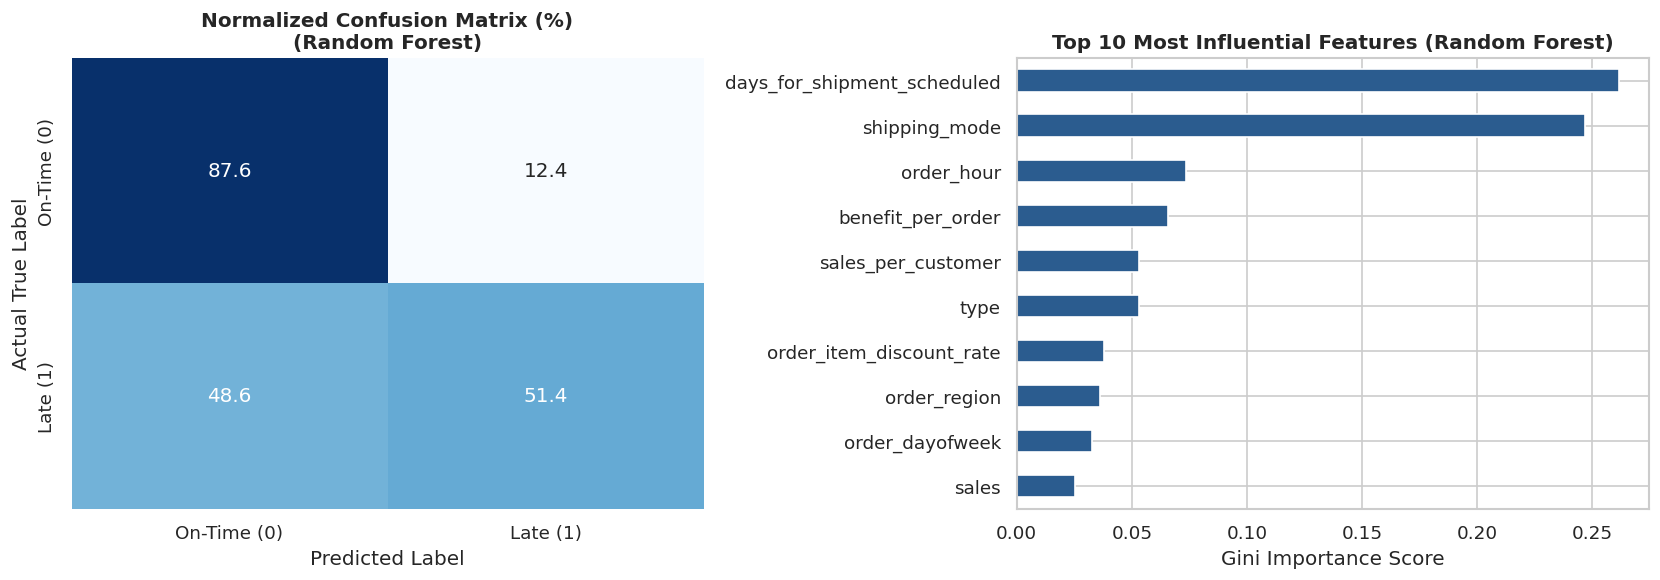

In [ ]:
# Evaluate the best model via confusion matrix and feature importance plot

# Identify best performing model from leaderboard
best_model_name = leaderboard.iloc[0]["Model"]
best_preds = model_predictions[best_model_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Normalized Confusion Matrix
cm = confusion_matrix(y_test, best_preds, normalize="true") * 100
sns.heatmap(
    cm,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar=False,
    xticklabels=["On-Time (0)", "Late (1)"],
    yticklabels=["On-Time (0)", "Late (1)"],
    ax=axes[0],
)
axes[0].set_title(
    f"Normalized Confusion Matrix (%)\n({best_model_name})",
    fontsize=12,
    fontweight="bold",
)
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("Actual True Label")

# Plot 2: Top 10 Feature Importances (from Random Forest)
rf_model = candidate_models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=True).tail(10)

top_features.plot(kind="barh", color="#2b5c8f", ax=axes[2 - 1])
axes[1].set_title(
    "Top 10 Most Influential Features (Random Forest)",
    fontsize=12,
    fontweight="bold",
)
axes[1].set_xlabel("Gini Importance Score")

plt.tight_layout()
plt.show()

In [ ]:
#  Print structured classification report and business takeaways for portfolio documentation

print(
    f"=== FINAL MODEL EVALUATION SUMMARY: {best_model_name.upper()} ==="
)
print(classification_report(y_test, best_preds, digits=3))

print("\n--- Business Insights for LinkedIn / Portfolio ---")
print("1. Problem Statement: Predict e-commerce late delivery risks prior to order fulfillment.")
print("2. Methodology: Cleaned 180,000+ transaction records, eliminated temporal data leakage, and compared 3 models.")
print(f"3. Champion Model: {best_model_name} achieved {leaderboard.iloc[0]['Accuracy (%)']}% Accuracy and {leaderboard.iloc[0]['F1-Score (%)']}% F1-Score.")
print("4. Key Operational Driver: Shipping Mode and Scheduled Shipment Days are the strongest determinants of late risk.")

=== FINAL MODEL EVALUATION SUMMARY: RANDOM FOREST ===
              precision    recall  f1-score   support

           0      0.624     0.876     0.729      1524
           1      0.819     0.514     0.632      1660

    accuracy                          0.688      3184
   macro avg      0.721     0.695     0.680      3184
weighted avg      0.725     0.688     0.678      3184


--- Business Insights for LinkedIn / Portfolio ---
1. Problem Statement: Predict e-commerce late delivery risks prior to order fulfillment.
2. Methodology: Cleaned 180,000+ transaction records, eliminated temporal data leakage, and compared 3 models.
3. Champion Model: Random Forest achieved 68.75% Accuracy and 63.19% F1-Score.
4. Key Operational Driver: Shipping Mode and Scheduled Shipment Days are the strongest determinants of late risk.
